# Pelatihan Model Klasifikasi — SISTA MIF

## 1. Import Library & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import json
import warnings
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

BASE_DIR   = Path.cwd()
TRAIN_FILE = BASE_DIR / "processed" / "training_corpus.csv"
TEST_FILE  = BASE_DIR / "processed" / "test_set.csv"
ML_DIR     = BASE_DIR.parent / "fastapi" / "ml_assets"
ML_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CLASSES       = ["Programmer", "Data Analyst", "Wirausaha Informatika", "Non-IT"]
CONFIDENCE_THRESHOLD = 0.50
COLORS               = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

STOPWORDS = {
    "yang", "di", "ke", "dari", "dan", "atau", "dengan", "untuk", "pada", "dalam",
    "adalah", "ini", "itu", "tidak", "juga", "sudah", "akan", "bisa", "ada", "oleh",
    "karena", "secara", "serta", "sebagai", "bagi", "telah", "maka", "namun", "sehingga",
    "jika", "agar", "ketika", "saat", "sebelum", "sesudah", "hingga", "sampai", "antara",
    "sekitar", "hanya", "saja", "belum", "masih", "lagi", "pun", "justru", "walaupun",
    "meskipun", "bahkan", "cukup", "sangat", "paling", "lebih", "kurang", "lain",
    "macam", "cara", "hal", "tentang", "mengenai", "terhadap", "kepada", "menuju",
    "kecuali", "selain", "tanpa", "demi", "guna", "khususnya", "umumnya", "kebanyakan",
    "sebagian", "beberapa", "semua", "setiap", "tiap", "satu", "dua", "tiga", "empat",
    "lima", "enam", "tujuh", "delapan", "sembilan", "sepuluh", "ratus", "ribu", "juta"
}

print("Konfigurasi selesai.")
print(f"   Training file : {TRAIN_FILE}")
print(f"   Test file     : {TEST_FILE}")
print(f"   Model output  : {ML_DIR}")

Konfigurasi selesai.
   Training file : d:\Project\sista_mif_ta\data\processed\training_corpus.csv
   Test file     : d:\Project\sista_mif_ta\data\processed\test_set.csv
   Model output  : d:\Project\sista_mif_ta\fastapi\ml_assets


## 2. Definisi Fungsi & Pipeline

In [2]:
def preprocess_text(text):
    """Pembersihan dasar — tanpa stemming ulang karena korpus sudah di-stem."""
    if pd.isna(text) or not isinstance(text, str): return ""
    text = text.lower().strip()
    if text in {"nan", "none", "null", "-", "0", "", "tidak diisi"}: return ""
    text = text.replace('-', ' ').replace('/', ' ').replace('_', ' ').replace(',', ' ')
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(words)

def get_pipeline():
    """Fungsi helper untuk memastikan konsistensi pipeline antara K-Fold dan Final Model."""
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=3000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=2,
            norm='l2'
        )),
        ('clf', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=42
        ))
    ])

print("Pipeline TF-IDF + Logistic Regression siap.")
print("   - TF-IDF : max_features=3000, ngram=(1,2), sublinear_tf=True, min_df=2")
print("   - LR     : max_iter=2000, class_weight='balanced', solver='lbfgs'")

Pipeline TF-IDF + Logistic Regression siap.
   - TF-IDF : max_features=3000, ngram=(1,2), sublinear_tf=True, min_df=2
   - LR     : max_iter=2000, class_weight='balanced', solver='lbfgs'


## 3. Memuat & Memproses Data

In [3]:
assert TRAIN_FILE.exists(), "File training_corpus.csv tidak ditemukan. Jalankan prepare_corpus.ipynb terlebih dahulu."

df_train = pd.read_csv(TRAIN_FILE, sep=";", dtype=str).dropna(subset=["job_text_raw", "label"])
df_test  = pd.read_csv(TEST_FILE,  sep=";", dtype=str).dropna(subset=["job_text_raw", "label"]) if TEST_FILE.exists() else None

print("Sedang memproses teks...")
X_train = df_train["job_text_raw"].apply(preprocess_text)
y_train = df_train["label"]
mask = X_train.str.len() > 0
X_train, y_train = X_train[mask], y_train[mask]

X_test, y_test = pd.Series(dtype=str), pd.Series(dtype=str)
if df_test is not None:
    X_test = df_test["job_text_raw"].apply(preprocess_text)
    y_test = df_test["label"]
    mask_t = X_test.str.len() > 0
    X_test, y_test = X_test[mask_t], y_test[mask_t]

print(f"\nData siap:")
print(f"   Jumlah data latih : {len(X_train)} baris")
print(f"   Jumlah data uji   : {len(X_test)} baris")
print("\nDistribusi label training:")
print(y_train.value_counts().to_string())

Sedang memproses teks...

Data siap:
   Jumlah data latih : 250 baris
   Jumlah data uji   : 107 baris

Distribusi label training:
label
Wirausaha Informatika    89
Non-IT                   87
Programmer               68
Data Analyst              6


## 4. K-Fold Cross Validation (5 Lipatan)

In [4]:
print("Melakukan pengujian K-Fold (5 putaran) pada data latih...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []

for i, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train)):
    model = get_pipeline()
    model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    y_pred = model.predict(X_train.iloc[te_idx])
    rep = classification_report(y_train.iloc[te_idx], y_pred, output_dict=True, zero_division=0)
    fold_metrics.append(rep)
    print(f"  Fold {i+1}/5  ->  Akurasi: {rep['accuracy']:.4f}")

avg_acc = np.mean([f['accuracy'] for f in fold_metrics])
std_acc = np.std([f['accuracy'] for f in fold_metrics])

print(f"\nRATA-RATA PENGUJIAN K-FOLD:")
print(f"   Akurasi Keseluruhan : {avg_acc:.4f} +/- {std_acc:.4f}")
print()
for cls in TARGET_CLASSES:
    p  = np.mean([f.get(cls, {}).get('precision', 0) for f in fold_metrics])
    r  = np.mean([f.get(cls, {}).get('recall', 0) for f in fold_metrics])
    f1 = np.mean([f.get(cls, {}).get('f1-score', 0) for f in fold_metrics])
    print(f"   {cls:25} | P: {p:.3f} | R: {r:.3f} | F1: {f1:.3f}")

Melakukan pengujian K-Fold (5 putaran) pada data latih...
  Fold 1/5  ->  Akurasi: 0.8200
  Fold 2/5  ->  Akurasi: 0.7400
  Fold 3/5  ->  Akurasi: 0.7200
  Fold 4/5  ->  Akurasi: 0.7200
  Fold 5/5  ->  Akurasi: 0.5600

RATA-RATA PENGUJIAN K-FOLD:
   Akurasi Keseluruhan : 0.7120 +/- 0.0845

   Programmer                | P: 0.978 | R: 0.398 | F1: 0.549
   Data Analyst              | P: 0.132 | R: 0.500 | F1: 0.207
   Wirausaha Informatika     | P: 0.788 | R: 0.737 | F1: 0.746
   Non-IT                    | P: 0.706 | R: 0.942 | F1: 0.805


### Visualisasi Akurasi per Fold

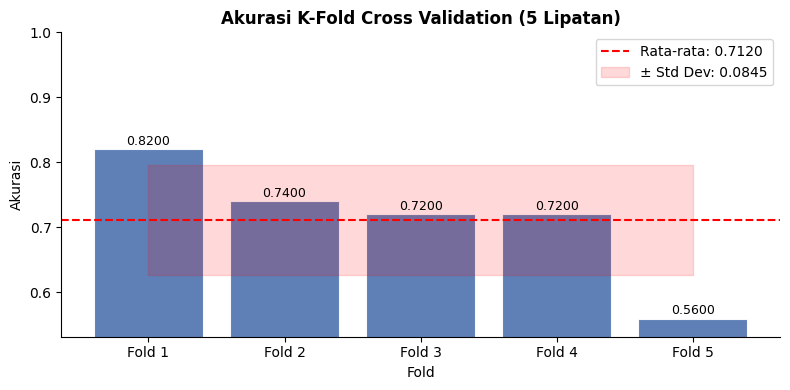

In [5]:
fold_accs = [f['accuracy'] for f in fold_metrics]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f"Fold {i+1}" for i in range(5)], fold_accs,
              color=COLORS[0], edgecolor="white", linewidth=0.8, alpha=0.9)
ax.axhline(avg_acc, color="red", linestyle="--", linewidth=1.5, label=f"Rata-rata: {avg_acc:.4f}")
ax.fill_between(range(5), avg_acc - std_acc, avg_acc + std_acc,
                alpha=0.15, color="red", label=f"± Std Dev: {std_acc:.4f}")
for bar, val in zip(bars, fold_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(min(fold_accs) * 0.95, 1.0)
ax.set_xlabel("Fold"); ax.set_ylabel("Akurasi")
ax.set_title("Akurasi K-Fold Cross Validation (5 Lipatan)", fontsize=12, fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Visualisasi F1-Score per Kelas (Rata-rata K-Fold)

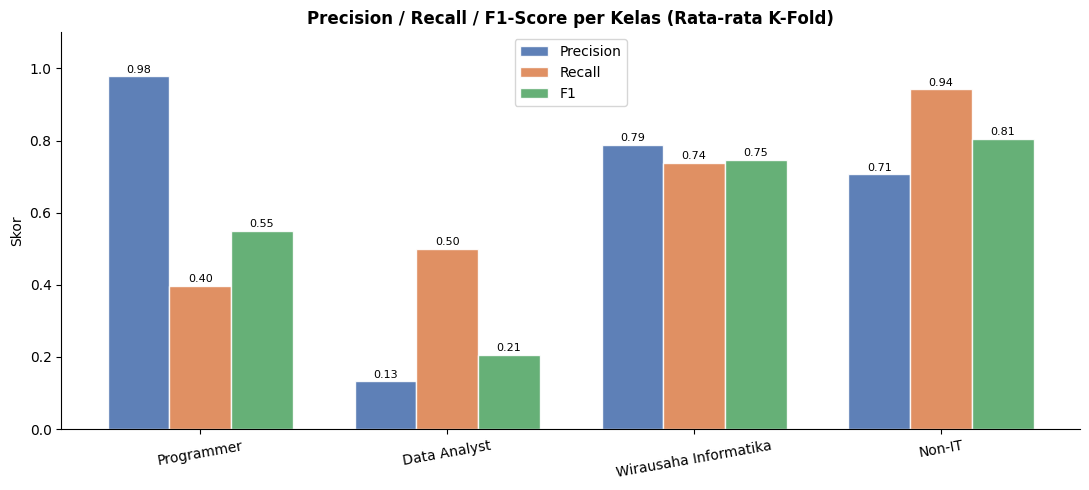

In [6]:
metrics_summary = {
    cls: {
        "precision": np.mean([f.get(cls, {}).get('precision', 0) for f in fold_metrics]),
        "recall":    np.mean([f.get(cls, {}).get('recall', 0) for f in fold_metrics]),
        "f1":        np.mean([f.get(cls, {}).get('f1-score', 0) for f in fold_metrics]),
    }
    for cls in TARGET_CLASSES
}

x = np.arange(len(TARGET_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for j, (metric, color) in enumerate([("precision", "#4C72B0"), ("recall", "#DD8452"), ("f1", "#55A868")]):
    vals = [metrics_summary[cls][metric] for cls in TARGET_CLASSES]
    bars = ax.bar(x + j * width, vals, width, label=metric.capitalize(), color=color, edgecolor="white", alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(TARGET_CLASSES, rotation=10)
ax.set_ylim(0, 1.1); ax.set_ylabel("Skor")
ax.set_title("Precision / Recall / F1-Score per Kelas (Rata-rata K-Fold)", fontsize=12, fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Pelatihan Model Final

In [7]:
print("Membuat model final dari seluruh data latih yang tersedia...")
final_model = get_pipeline()
final_model.fit(X_train, y_train)
print("Model final berhasil dilatih.")

Membuat model final dari seluruh data latih yang tersedia...
Model final berhasil dilatih.


## 6. Evaluasi pada Hold-Out Test Set

In [8]:
metrics_test = None
if len(X_test) > 0:
    y_pred = final_model.predict(X_test)
    rep_test = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    metrics_test = rep_test

    print("HASIL PENGUJIAN PADA DATA TEST:")
    print(classification_report(y_test, y_pred, zero_division=0))

    for cls in TARGET_CLASSES:
        sup = rep_test[cls]['support'] if cls in rep_test else 0
        if sup < 5:
            print(f"Catatan: Kelas '{cls}' hanya punya {sup} data uji — skor F1-nya mungkin kurang akurat.")
else:
    print("Tidak ada data test. Lewati evaluasi.")

HASIL PENGUJIAN PADA DATA TEST:
                       precision    recall  f1-score   support

         Data Analyst       0.00      0.00      0.00         2
               Non-IT       0.77      0.94      0.85        36
           Programmer       0.95      0.63      0.76        30
Wirausaha Informatika       0.86      0.92      0.89        39

             accuracy                           0.83       107
            macro avg       0.64      0.63      0.62       107
         weighted avg       0.84      0.83      0.82       107

Catatan: Kelas 'Data Analyst' hanya punya 2.0 data uji — skor F1-nya mungkin kurang akurat.


### 6a. Confusion Matrix

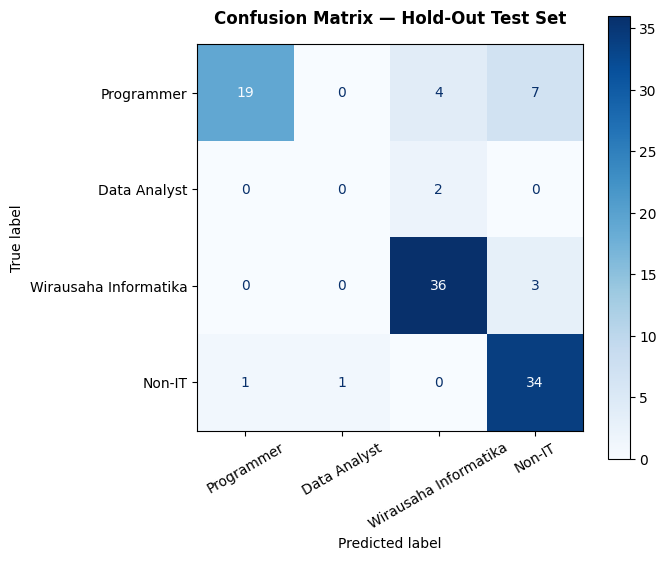

   Disimpan ke: d:\Project\sista_mif_ta\fastapi\ml_assets\confusion_matrix_test.png


In [9]:
if len(X_test) > 0:
    cm = confusion_matrix(y_test, y_pred, labels=TARGET_CLASSES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_CLASSES)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap='Blues', values_format='d', xticks_rotation=30, colorbar=True, ax=ax)
    ax.set_title('Confusion Matrix — Hold-Out Test Set', fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(ML_DIR / 'confusion_matrix_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"   Disimpan ke: {ML_DIR / 'confusion_matrix_test.png'}")

### 6b. Distribusi Confidence Score

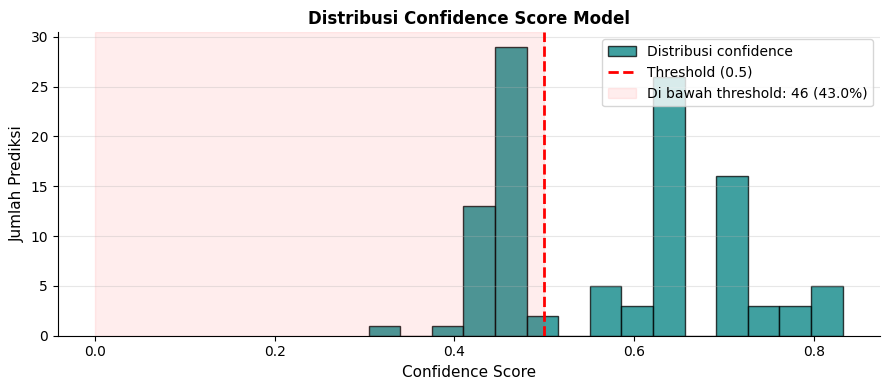


   46 dari 107 prediksi (43.0%) di bawah threshold 0.5.
   Disimpan ke: d:\Project\sista_mif_ta\fastapi\ml_assets\confidence_distribution.png


In [10]:
if len(X_test) > 0:
    proba = final_model.predict_proba(X_test)
    max_p = np.max(proba, axis=1)
    below = np.sum(max_p < CONFIDENCE_THRESHOLD)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(max_p, bins=15, edgecolor='black', alpha=0.75, color='teal', label='Distribusi confidence')
    ax.axvline(x=CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2,
               label=f'Threshold ({CONFIDENCE_THRESHOLD})')
    ax.axvspan(0, CONFIDENCE_THRESHOLD, alpha=0.07, color='red', label=f'Di bawah threshold: {below} ({below/len(max_p)*100:.1f}%)')
    ax.set_xlabel('Confidence Score', fontsize=11)
    ax.set_ylabel('Jumlah Prediksi', fontsize=11)
    ax.set_title('Distribusi Confidence Score Model', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(ML_DIR / 'confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n   {below} dari {len(max_p)} prediksi ({below/len(max_p)*100:.1f}%) di bawah threshold {CONFIDENCE_THRESHOLD}.")
    print(f"   Disimpan ke: {ML_DIR / 'confidence_distribution.png'}")

### 6c. Feature Importance (Kata Paling Berpengaruh)

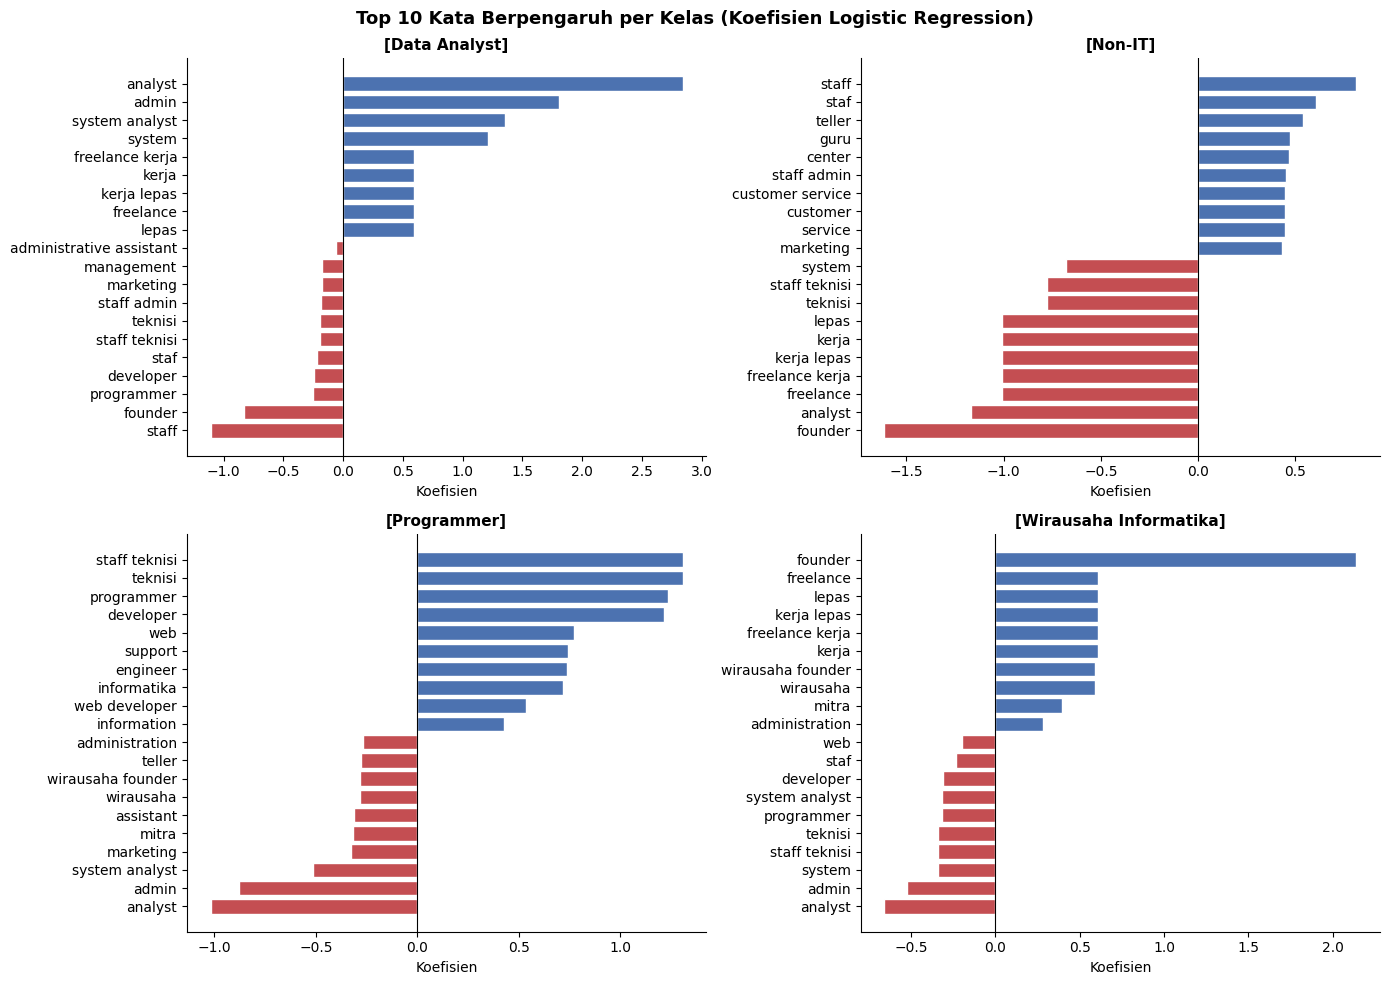


3 KATA PALING BERPENGARUH (POSITIF & NEGATIF) TIAP KELAS:
  [Data Analyst]
    Mendorong (+) : analyst(2.84), admin(1.81), system analyst(1.36)
    Menghambat (-): staff(-1.11), founder(-0.83), programmer(-0.25)
  [Non-IT]
    Mendorong (+) : staff(0.81), staf(0.61), teller(0.54)
    Menghambat (-): founder(-1.61), analyst(-1.17), freelance(-1.01)
  [Programmer]
    Mendorong (+) : teknisi(1.31), staff teknisi(1.31), programmer(1.24)
    Menghambat (-): analyst(-1.02), admin(-0.88), system analyst(-0.51)
  [Wirausaha Informatika]
    Mendorong (+) : founder(2.14), kerja lepas(0.61), kerja(0.61)
    Menghambat (-): analyst(-0.66), admin(-0.52), system(-0.34)


In [11]:
if len(X_test) > 0:
    vec   = final_model.named_steps['tfidf']
    clf   = final_model.named_steps['clf']
    feats = vec.get_feature_names_out()
    coeffs = clf.coef_

    TOP_N = 10
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Top {TOP_N} Kata Berpengaruh per Kelas (Koefisien Logistic Regression)",
                 fontsize=13, fontweight="bold")

    for ax, (cls_idx, cls) in zip(axes.flat, enumerate(clf.classes_)):
        coef = coeffs[cls_idx]
        top_pos_idx = coef.argsort()[-TOP_N:][::-1]
        top_neg_idx = coef.argsort()[:TOP_N]
        combined_idx = np.concatenate([top_pos_idx, top_neg_idx])
        combined_vals = coef[combined_idx]
        combined_words = feats[combined_idx]
        colors_bar = ["#4C72B0" if v > 0 else "#C44E52" for v in combined_vals]

        sorted_order = np.argsort(combined_vals)
        ax.barh(combined_words[sorted_order], combined_vals[sorted_order],
                color=[colors_bar[i] for i in sorted_order], edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f"[{cls}]", fontsize=11, fontweight="bold")
        ax.set_xlabel("Koefisien")
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    print("\n3 KATA PALING BERPENGARUH (POSITIF & NEGATIF) TIAP KELAS:")
    for i, cls in enumerate(clf.classes_):
        pos_idx = coeffs[i].argsort()[-3:][::-1]
        neg_idx = coeffs[i].argsort()[:3]
        top_pos = [(feats[j], coeffs[i][j]) for j in pos_idx if coeffs[i][j] > 0]
        top_neg = [(feats[j], coeffs[i][j]) for j in neg_idx if coeffs[i][j] < 0]
        pos_str = ", ".join([f"{w}({c:.2f})" for w, c in top_pos]) if top_pos else "Tidak ada"
        neg_str = ", ".join([f"{w}({c:.2f})" for w, c in top_neg]) if top_neg else "Tidak ada"
        print(f"  [{cls}]")
        print(f"    Mendorong (+) : {pos_str}")
        print(f"    Menghambat (-): {neg_str}")

### 6d. Prediksi yang Meleset

In [12]:
if len(X_test) > 0:
    mis = np.where(y_test.values != y_pred)[0]
    if len(mis) > 0:
        print(f"{len(mis)} prediksi meleset dari {len(y_test)} total data uji:\n")
        rows = []
        for idx in mis[:min(10, len(mis))]:
            rows.append({
                "Teks (cuplikan)": df_test.iloc[idx]['job_text_raw'][:60] + "...",
                "Label Seharusnya": y_test.iloc[idx],
                "Prediksi Model": y_pred[idx],
            })
        pd.DataFrame(rows)
    else:
        print("Semua prediksi pada test set benar!")

18 prediksi meleset dari 107 total data uji:



## 7. Simpan Model & Metrik

In [13]:
model_path = ML_DIR / "ml_pipeline_internal.pkl"
joblib.dump(final_model, model_path)

metrics = {
    "methodology": "Internal MIF only",
    "k_fold": {
        "accuracy_mean": float(avg_acc),
        "accuracy_std":  float(np.std([f['accuracy'] for f in fold_metrics])),
        "folds": fold_metrics
    },
    "threshold_config": CONFIDENCE_THRESHOLD
}
if metrics_test:
    metrics["hold_out_test"] = metrics_test

metrics_file = ML_DIR / "metrics_internal_only.json"
with open(metrics_file, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f"Model berhasil disimpan di : {model_path}")
print(f"Metrik disimpan di         : {metrics_file}")
print(f"\n   Akurasi rata-rata K-Fold  : {avg_acc:.4f} +/- {np.std([f['accuracy'] for f in fold_metrics]):.4f}")
if metrics_test:
    print(f"   Weighted F1 (test set)    : {metrics_test.get('weighted avg', {}).get('f1-score', 0):.4f}")

Model berhasil disimpan di : d:\Project\sista_mif_ta\fastapi\ml_assets\ml_pipeline_internal.pkl
Metrik disimpan di         : d:\Project\sista_mif_ta\fastapi\ml_assets\metrics_internal_only.json

   Akurasi rata-rata K-Fold  : 0.7120 +/- 0.0845
   Weighted F1 (test set)    : 0.8231
